# Импорты

In [1]:
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False

SEED = 42

# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"
print("Устройство для работы:", DEVICE)
# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

Устройство для работы: cpu
NumPy: 2.3.5
Pandas: 2.3.3
FAISS доступен: True
sentence-transformers доступен: True


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


# База знаний

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Зигмунд Фрейд и основы психоанализа",
        "text": (
            "Зигмунд Фрейд основал психоанализ в конце XIX века как метод лечения и теорию личности. "
            "Этот подход изучает бессознательные процессы, влияющие на поведение человека. "
            "Основные идеи включают роль детских травм, сновидений и бессознательных конфликтов."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Бессознательное",
        "text": (
            "Бессознательное – центральное понятие психоанализа. "
            "Оно содержит вытесненные желания, воспоминания и импульсы, недоступные сознанию. "
            "Однако бессознательное активно влияет на мысли, чувства и поступки человека."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Структура личности: Оно, Я, Сверх-Я",
        "text": (
            "Фрейд выделил три инстанции психики: Оно (инстинкты), Я (реальность) и Сверх-Я (мораль). "
            "Оно требует немедленного удовлетворения желаний, а Сверх-Я накладывает ограничения. "
            "Я балансирует между ними, адаптируя человека к внешней среде."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Защитные механизмы психики",
        "text": (
            "Защитные механизмы используются Я для снижения тревоги и сохранения целостности. "
            "К ним относятся вытеснение, проекция, рационализация и сублимация. "
            "Чрезмерное использование защит может приводить к неврозам и искажению реальности."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Толкование сновидений",
        "text": (
            "Фрейд называл сновидения «королевской дорогой к бессознательному». "
            "Сновидения рассматриваются как замаскированное исполнение вытесненных желаний. "
            "Анализ символов снов помогает понять скрытые конфликты пациента."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Психосексуальное развитие",
        "text": (
            "Психоанализ предполагает, что личность формируется через стадии психосексуального развития. "
            "Стадии включают оральную, анальную, фаллическую, латентную и генитальную. "
            "Фиксация на одной из стадий может определить черты характера во взрослом возрасте."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Эдипов комплекс",
        "text": (
            "Эдипов комплекс возникает в фаллической стадии развития у детей. "
            "Он характеризуется бессознательным влечением к родителю противоположного пола и ревностью к родителю своего пола. "
            "Успешное разрешение этого конфликта важно для формирования идентичности."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Либидо и инстинкты",
        "text": (
            "Либидо в психоанализе – это психическая энергия сексуальных влечений. "
            "Фрейд также выделял инстинкт смерти (Танатос) как противоположность инстинкту жизни (Эрос). "
            "Баланс этих сил определяет динамику психической жизни."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Метод свободных ассоциаций",
        "text": (
            "Свободные ассоциации – основной технический прием психоанализа. "
            "Пациент говорит все, что приходит в голову, без цензуры и логической связности. "
            "Это позволяет обойти защиты и выявить бессознательный материал."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Перенос в терапии",
        "text": (
            "Перенос – это процесс, когда пациент бессознательно проецирует на аналитика чувства к значимым фигурам прошлого. "
            "Анализ переноса является ключевым инструментом терапии. "
            "Через него прорабатываются старые конфликты в безопасной обстановке."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Контрперенос",
        "text": (
            "Контрперенос – это эмоциональная реакция аналитика на пациента. "
            "Раньше это считалось помехой, сейчас признается важным источником информации. "
            "Аналитик должен осознавать свои чувства, чтобы использовать их в работе, а не действовать под их влиянием."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Сопротивление",
        "text": (
            "Сопротивление – это силы, которые препятствуют продвижению терапии и осознанию бессознательного. "
            "Оно может проявляться в опозданиях, молчании или отрицании интерпретаций. "
            "Преодоление сопротивления – необходимая часть аналитической работы."
        ),
    },
    {
        "doc_id": "doc_13",
        "title": "Карл Юнг и архетипы",
        "text": (
            "Карл Юнг развивал аналитическую психологию, введя понятие коллективного бессознательного. "
            "Архетипы – это универсальные врожденные психические структуры, такие как Тень, Анима, Анимус. "
            "Индивидуация – процесс становления целостной личности через интеграцию этих частей."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Альфред Адлер и комплекс неполноценности",
        "text": (
            "Альфред Адлер создал индивидуальную психологию, акцентируя внимание на социальных факторах. "
            "Комплекс неполноценности возникает из чувства слабости в детстве. "
            "Стремление к превосходству является главной движущей силой поведения человека."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Неофрейдизм",
        "text": (
            "Неофрейдисты (Фромм, Хорни, Салливан) пересмотрели биологизаторский подход Фрейда. "
            "Они уделили больше внимания культуре, обществу и межличностным отношениям. "
            "Тревога рассматривается как результат социальных противоречий, а не только внутренних конфликтов."
        ),
    },
    {
        "doc_id": "doc_16",
        "title": "Теория объектных отношений",
        "text": (
            "Эта теория фокусируется на том, как человек формирует образы себя и других в раннем детстве. "
            "Внутренние объекты влияют на то, как мы строим отношения во взрослой жизни. "
            "Ключевые фигуры: Мелани Кляйн, Дональд Винникотт."
        ),
    },
    {
        "doc_id": "doc_017",
        "title": "Оговорки по Фрейду",
        "text": (
            "Парапраксис, или оговорка по Фрейду, – это ошибка в речи, письме или действии. "
            "Считается, что такие ошибки не случайны, а выявляют скрытые мысли или желания. "
            "Анализ оговорок помогает понять бессознательные намерения."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Сеттинг в психоанализе",
        "text": (
            "Сеттинг – это постоянные рамки терапии: время, место, частота встреч и оплата. "
            "Стабильность сеттинга создает безопасное пространство для работы. "
            "Нарушения сеттинга часто анализируются как проявление сопротивления или переноса."
        ),
    },
    {
        "doc_id": "doc_19",
        "title": "Интерпретация",
        "text": (
            "Интерпретация – это объяснение аналитиком скрытого смысла слов, снов или действий пациента. "
            "Своевременная и точная интерпретация способствует инсайту. "
            "Преждевременная интерпретация может усилить сопротивление."
        ),
    },
    {
        "doc_id": "doc_20",
        "title": "Критика и современный психоанализ",
        "text": (
            "Психоанализ критиковали за недостаточную научную доказательность и пансексуализм. "
            "Современный психоанализ эволюционировал, интегрируя данные нейронаук и исследований привязанности. "
            "Он остается влиятельным методом глубинной психотерапии."
        ),
    },
]

print(f"Количество документов: {len(documents)}")
docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title"]])

Количество документов: 20


,doc_id,title
0,doc_01,Зигмунд Фрейд и основы психоанализа
1,doc_02,Бессознательное
2,doc_03,"Структура личности: Оно, Я, Сверх-Я"
3,doc_04,Защитные механизмы психики
4,doc_05,Толкование сновидений
5,doc_06,Психосексуальное развитие
6,doc_07,Эдипов комплекс
7,doc_08,Либидо и инстинкты
8,doc_09,Метод свободных ассоциаций
9,doc_10,Перенос в терапии


In [4]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

In [5]:
artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 36


,doc_id,title,chunk_id,chunk_text
0,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_01,Зигмунд Фрейд основал психоанализ в конце XIX ...
1,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_02,"процессы, влияющие на поведение человека. Осно..."
2,doc_02,Бессознательное,doc_02_chunk_01,Бессознательное – центральное понятие психоана...
3,doc_03,"Структура личности: Оно, Я, Сверх-Я",doc_03_chunk_01,Фрейд выделил три инстанции психики: Оно (инст...
4,doc_03,"Структура личности: Оно, Я, Сверх-Я",doc_03_chunk_02,Сверх-Я накладывает ограничения. Я балансирует...


# Контрольные запросы и оценка Retrieval

In [6]:

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks

class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_READY:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)

In [7]:
benchmark_queries: List[Dict[str, object]] = [
{
    "query_id": "q01",
    "query": "Кто основал психоанализ и какие идеи лежат в его основе?",
    "relevant_doc_ids": ["doc_01"],
    #"expected_keywords": ["Фрейд", "бессознательные", "детских травм", "сновидений"],
    },
    {
    "query_id": "q02",
    "query": "Что такое бессознательное в психоанализе?",
    "relevant_doc_ids": ["doc_02"],
    #"expected_keywords": ["вытесненные", "желания", "воспоминания", "импульсы"],
    },
    {
    "query_id": "q03",
    "query": "Из каких частей состоит структура личности по Фрейду?",
    "relevant_doc_ids": ["doc_03"],
    #"expected_keywords": ["Оно", "Я", "Сверх-Я", "инстинкты", "мораль"],
    },
    {
    "query_id": "q04",
    "query": "Какие защитные механизмы психики выделяет психоанализ?",
    "relevant_doc_ids": ["doc_04"],
    #"expected_keywords": ["вытеснение", "проекция", "рационализация", "сублимация"],
    },
    {
    "query_id": "q05",
    "query": "Почему сновидения важны для психоанализа?",
    "relevant_doc_ids": ["doc_05"],
    #"expected_keywords": ["королевской дорогой", "бессознательному", "исполнение", "желаний"],
    },
    {
    "query_id": "q06",
    "query": "Какие стадии психосексуального развития описывает Фрейд?",
    "relevant_doc_ids": ["doc_06"],
    #"expected_keywords": ["оральную", "анальную", "фаллическую", "латентную", "генитальную"],
    },
    {
    "query_id": "q07",
    "query": "Что такое Эдипов комплекс и когда он возникает?",
    "relevant_doc_ids": ["doc_07"],
    #"expected_keywords": ["фаллической", "влечение", "родителю", "противоположного пола"],
    },
    {
    "query_id": "q08",
    "query": "Как психоанализ понимает либидо и инстинкты?",
    "relevant_doc_ids": ["doc_08"],
    #"expected_keywords": ["психическая энергия", "Эрос", "Танатос", "инстинкт жизни"],
    },
    {
    "query_id": "q09",
    "query": "В чём суть метода свободных ассоциаций?",
    "relevant_doc_ids": ["doc_09"],
    #"expected_keywords": ["говорит все", "без цензуры", "бессознательный материал"],
    },
    {
    "query_id": "q10",
    "query": "Что такое перенос в психоаналитической терапии?",
    "relevant_doc_ids": ["doc_10"],
    #"expected_keywords": ["проецирует", "аналитика", "значимым фигурам", "прошлого"],
    },
    {
    "query_id": "q11",
    "query": "Как аналитик должен работать с контрпереносом?",
    "relevant_doc_ids": ["doc_11"],
    #"expected_keywords": ["эмоциональная реакция", "источник информации", "осознавать"],
    },
    {
    "query_id": "q12",
    "query": "Как проявляется сопротивление в терапии?",
    "relevant_doc_ids": ["doc_12"],
    #"expected_keywords": ["опозданиях", "молчании", "отрицании", "интерпретаций"],
    },
    {
    "query_id": "q13",
    "query": "Что такое архетипы по Карлу Юнгу?",
    "relevant_doc_ids": ["doc_13"],
    #"expected_keywords": ["коллективного бессознательного", "Тень", "Анима", "Индивидуация"],
    },
    {
    "query_id": "q14",
    "query": "В чём суть теории Адлера о комплексе неполноценности?",
    "relevant_doc_ids": ["doc_14"],
    #"expected_keywords": ["чувство слабости", "детстве", "стремление к превосходству"],
    },
    {
    "query_id": "q15",
    "query": "Чем неофрейдизм отличается от классического психоанализа?",
    "relevant_doc_ids": ["doc_15"],
    #"expected_keywords": ["культуре", "обществу", "межличностным отношениям", "социальных"],
    },
    {
    "query_id": "q16",
    "query": "Что изучает теория объектных отношений?",
    "relevant_doc_ids": ["doc_16"],
    #"expected_keywords": ["образы себя", "других", "раннем детстве", "внутренние объекты"],
    },
    {
    "query_id": "q17",
    "query": "Почему оговорки по Фрейду не считаются случайными?",
    "relevant_doc_ids": ["doc_17"],
    #"expected_keywords": ["парапраксис", "скрытые мысли", "бессознательные намерения"],
    },
    {
    "query_id": "q18",
    "query": "Зачем нужен стабильный сеттинг в психоанализе?",
    "relevant_doc_ids": ["doc_18"],
    #"expected_keywords": ["постоянные рамки", "безопасное пространство", "нарушения"],
    },
    {
    "query_id": "q19",
    "query": "Как должна проводиться интерпретация в терапии?",
    "relevant_doc_ids": ["doc_19"],
    #"expected_keywords": ["скрытого смысла", "инсайту", "своевременная", "преждевременная"],
    },
    {
    "query_id": "q20",
    "query": "Как развивался психоанализ в ответ на критику?",
    "relevant_doc_ids": ["doc_20"],
    #"expected_keywords": ["научную доказательность", "нейронаук", "привязанности", "эволюционировал"],
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,Кто основал психоанализ и какие идеи лежат в е...,[doc_01]
1,q02,Что такое бессознательное в психоанализе?,[doc_02]
2,q03,Из каких частей состоит структура личности по ...,[doc_03]
3,q04,Какие защитные механизмы психики выделяет псих...,[doc_04]
4,q05,Почему сновидения важны для психоанализа?,[doc_05]
5,q06,Какие стадии психосексуального развития описыв...,[doc_06]
6,q07,Что такое Эдипов комплекс и когда он возникает?,[doc_07]
7,q08,Как психоанализ понимает либидо и инстинкты?,[doc_08]
8,q09,В чём суть метода свободных ассоциаций?,[doc_09]
9,q10,Что такое перенос в психоаналитической терапии?,[doc_10]


In [8]:
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Кто основал психоанализ и какие идеи лежат в е...,doc_01,"doc_01, doc_20, doc_02",1,1.0,1.000000,1.0
1,q02,Что такое бессознательное в психоанализе?,doc_02,"doc_02, doc_01, doc_13",1,1.0,1.000000,1.0
2,q03,Из каких частей состоит структура личности по ...,doc_03,"doc_13, doc_06",0,0.0,0.000000,NaN
3,q04,Какие защитные механизмы психики выделяет псих...,doc_04,"doc_20, doc_01, doc_02",0,0.0,0.000000,NaN
4,q05,Почему сновидения важны для психоанализа?,doc_05,"doc_05, doc_02, doc_08",1,1.0,1.000000,1.0
5,q06,Какие стадии психосексуального развития описыв...,doc_06,"doc_06, doc_20, doc_07",1,1.0,1.000000,1.0
6,q07,Что такое Эдипов комплекс и когда он возникает?,doc_07,"doc_07, doc_13",1,1.0,1.000000,1.0
7,q08,Как психоанализ понимает либидо и инстинкты?,doc_08,"doc_08, doc_01, doc_20",1,1.0,1.000000,1.0
8,q09,В чём суть метода свободных ассоциаций?,doc_09,"doc_09, doc_13",1,1.0,1.000000,1.0
9,q10,Что такое перенос в психоаналитической терапии?,doc_10,"doc_20, doc_01, doc_10",1,1.0,0.333333,3.0


,metric,value
0,mean_hit@3,0.750000
1,mean_recall@3,0.750000
2,mean_MRR@3,0.658333


Для production-системы такой показатель hit@3 = 0.75 является отличным результатом. Можно рассмотреть использование top_k=3 как баланс между точностью (75%) и производительностью. 

In [9]:
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,40,10,20,SentenceTransformer: sentence-transformers/par...,0.85,0.85,0.700000
1,60,15,20,SentenceTransformer: sentence-transformers/par...,0.85,0.85,0.700000
2,28,8,29,SentenceTransformer: sentence-transformers/par...,0.80,0.80,0.691667
3,18,4,43,SentenceTransformer: sentence-transformers/par...,0.70,0.70,0.666667


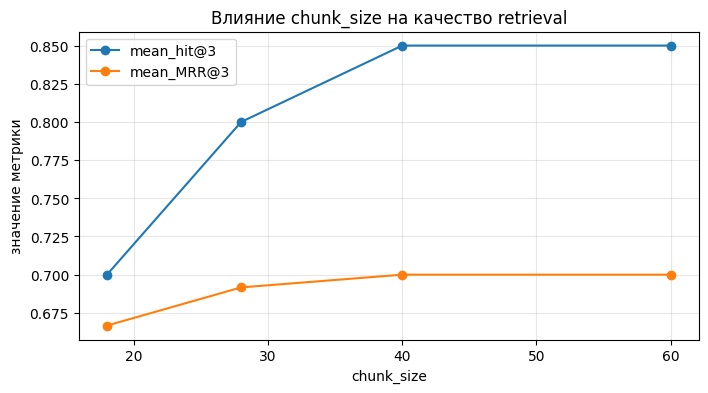

In [10]:
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
new_documents: List[Dict[str, str]] = [
    {
    "doc_id": "doc_21",
    "title": "Вытеснение как основной защитный механизм",
    "text": (
        "Вытеснение — фундаментальный защитный механизм, при котором тревожащие мысли и желания удаляются из сознания в бессознательное. "
        "Фрейд считал его основой всех других защит. "
        "Однако вытесненный материал не исчезает, а продолжает влиять на поведение, проявляясь в симптомах, оговорках и сновидениях."
    ),
},
{
    "doc_id": "doc_22",
    "title": "Сублимация и творчество в психоанализе",
    "text": (
        "Сублимация — это перенаправление сексуальной или агрессивной энергии в социально приемлемую деятельность: искусство, науку, работу. "
        "Фрейд рассматривал великие произведения культуры как результат сублимации либидо. "
        "В отличие от других защит, сублимация считается здоровым и адаптивным механизмом."
    ),
},
{
    "doc_id": "doc_23",
    "title": "Жак Лакан и структурный психоанализ",
    "text": (
        "Жак Лакан переосмыслил Фрейда через призму лингвистики и структурной антропологии. "
        "Он ввёл концепции Стадии зеркала, Реального, Символического и Воображаемого. "
        "Лакан подчёркивал, что «бессознательное структурировано как язык», а желание всегда опосредовано знаком и Другим."
    ),
},
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Что такое вытеснение?",
    "Как рассматривал Фрейд великие произведения культуры?",
    "Что подчеркивал Лакан?"
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])


,doc_id,title
0,doc_21,Вытеснение как основной защитный механизм
1,doc_22,Сублимация и творчество в психоанализе
2,doc_23,Жак Лакан и структурный психоанализ


### Как baseline-база отвечает на новые запросы

**Запрос:** Что такое вытеснение?

,rank,score,doc_id,title,chunk_text
0,1,0.533593,doc_12,Сопротивление,"Сопротивление – это силы, которые препятствуют..."
1,2,0.516683,doc_017,Оговорки по Фрейду,"Парапраксис, или оговорка по Фрейду, – это оши..."
2,3,0.488362,doc_02,Бессознательное,Бессознательное – центральное понятие психоана...


**Запрос:** Как рассматривал Фрейд великие произведения культуры?

,rank,score,doc_id,title,chunk_text
0,1,0.494593,doc_15,Неофрейдизм,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
1,2,0.399117,doc_13,Карл Юнг и архетипы,"Карл Юнг развивал аналитическую психологию, вв..."
2,3,0.383909,doc_01,Зигмунд Фрейд и основы психоанализа,Зигмунд Фрейд основал психоанализ в конце XIX ...


**Запрос:** Что подчеркивал Лакан?

,rank,score,doc_id,title,chunk_text
0,1,0.401222,doc_03,"Структура личности: Оно, Я, Сверх-Я",Фрейд выделил три инстанции психики: Оно (инст...
1,2,0.353270,doc_08,Либидо и инстинкты,Либидо в психоанализе – это психическая энерги...
2,3,0.334259,doc_16,Теория объектных отношений,"на то, как мы строим отношения во взрослой жиз..."


In [12]:
baseline_chunk_size = 28
baseline_overlap = 8

# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q21",
        "query": "Как рассматривал Фрейд великие произведения культуры?",
        "relevant_doc_ids": ["doc_22"],
    },
    {
        "query_id": "q22",
        "query": "КЧто подчеркивал Лакан?",
        "relevant_doc_ids": ["doc_23"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Кто основал психоанализ и какие идеи лежат в е...,doc_01,"doc_01, doc_20, doc_02",1,1.0,1.000000,1.0,"doc_01, doc_20, doc_02",1,1.0,1.000000,1.0
1,q02,Что такое бессознательное в психоанализе?,doc_02,"doc_02, doc_01, doc_13",1,1.0,1.000000,1.0,"doc_02, doc_13, doc_01",1,1.0,1.000000,1.0
2,q03,Из каких частей состоит структура личности по ...,doc_03,"doc_13, doc_06",0,0.0,0.000000,NaN,"doc_13, doc_16",0,0.0,0.000000,NaN
3,q04,Какие защитные механизмы психики выделяет псих...,doc_04,"doc_20, doc_01, doc_02",0,0.0,0.000000,NaN,"doc_20, doc_01, doc_21",0,0.0,0.000000,NaN
4,q05,Почему сновидения важны для психоанализа?,doc_05,"doc_05, doc_02, doc_08",1,1.0,1.000000,1.0,"doc_05, doc_02, doc_017",1,1.0,1.000000,1.0
5,q06,Какие стадии психосексуального развития описыв...,doc_06,"doc_06, doc_20, doc_07",1,1.0,1.000000,1.0,"doc_06, doc_01, doc_20",1,1.0,1.000000,1.0
6,q07,Что такое Эдипов комплекс и когда он возникает?,doc_07,"doc_07, doc_13",1,1.0,1.000000,1.0,"doc_07, doc_13",1,1.0,1.000000,1.0
7,q08,Как психоанализ понимает либидо и инстинкты?,doc_08,"doc_08, doc_01, doc_20",1,1.0,1.000000,1.0,"doc_08, doc_017, doc_01",1,1.0,1.000000,1.0
8,q09,В чём суть метода свободных ассоциаций?,doc_09,"doc_09, doc_13",1,1.0,1.000000,1.0,"doc_09, doc_13",1,1.0,1.000000,1.0
9,q10,Что такое перенос в психоаналитической терапии?,doc_10,"doc_20, doc_01, doc_10",1,1.0,0.333333,3.0,"doc_20, doc_10, doc_01",1,1.0,0.500000,2.0


,metric,before_update,after_update,delta
0,mean_hit@3,0.681818,0.772727,0.090909
1,mean_recall@3,0.681818,0.772727,0.090909
2,mean_MRR@3,0.598485,0.674242,0.075758


...

,rank,score,doc_id,title,chunk_text
0,1,0.590862,doc_21,Вытеснение как основной защитный механизм,Вытеснение — фундаментальный защитный механизм...
1,2,0.528827,doc_017,Оговорки по Фрейду,"Парапраксис, или оговорка по Фрейду, – это оши..."
2,3,0.522623,doc_12,Сопротивление,"Сопротивление – это силы, которые препятствуют..."


**Запрос:** Как рассматривал Фрейд великие произведения культуры?

,rank,score,doc_id,title,chunk_text
0,1,0.560551,doc_23,Жак Лакан и структурный психоанализ,Жак Лакан переосмыслил Фрейда через призму лин...
1,2,0.455873,doc_15,Неофрейдизм,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
2,3,0.427467,doc_22,Сублимация и творчество в психоанализе,Сублимация — это перенаправление сексуальной и...


**Запрос:** Что подчеркивал Лакан?

,rank,score,doc_id,title,chunk_text
0,1,0.597261,doc_23,Жак Лакан и структурный психоанализ,Жак Лакан переосмыслил Фрейда через призму лин...
1,2,0.392308,doc_23,Жак Лакан и структурный психоанализ,"подчёркивал, что «бессознательное структуриров..."
2,3,0.385038,doc_03,"Структура личности: Оно, Я, Сверх-Я",Фрейд выделил три инстанции психики: Оно (инст...


In [13]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

query = "Как эволюционировал современный психоанализ?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Как эволюционировал современный психоанализ?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.786295,doc_20,Критика и современный психоанализ,doc_20_chunk_01,Психоанализ критиковали за недостаточную научн...
1,2,0.763206,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_01,Зигмунд Фрейд основал психоанализ в конце XIX ...
2,3,0.624749,doc_06,Психосексуальное развитие,doc_06_chunk_01,"Психоанализ предполагает, что личность формиру..."


[Источник: doc_20 | Критика и современный психоанализ | score=0.7863]
Психоанализ критиковали за недостаточную научную доказательность и пансексуализм. Современный психоанализ эволюционировал, интегрируя данные нейронаук и исследований привязанности. Он остается влиятельным методом глубинной психотерапии.

[Источник: doc_01 | Зигмунд Фрейд и основы психоанализа | score=0.7632]
Зигмунд Фрейд основал психоанализ в конце XIX века как метод лечения и теорию личности. Этот подход изучает бессознательные процессы, влияющие на поведение человека. Основные

[Источник: doc_06 | Психосексуальное развитие | score=0.6247]
Психоанализ предполагает, что личность формируется через стадии психосексуального развития. Стадии включают оральную, анальную, фаллическую, латентную и генитальную. Фиксация на одной из стадий может определить


In [14]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

answer_example = generate_answer_from_context(query, context)
print(answer_example)

Современный психоанализ эволюционировал, интегрируя данные нейронаук и исследований привязанности. Зигмунд Фрейд основал психоанализ в конце XIX века как метод лечения и теорию личности.


In [15]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

rag_result = mini_rag_answer(
    "Что такое либидо?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Что такое либидо?

**Ответ:** Либидо в психоанализе – это психическая энергия сексуальных влечений. Считается, что такие ошибки не случайны, а выявляют скрытые мысли или

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.269702,doc_08,Либидо и инстинкты,doc_08_chunk_01,Либидо в психоанализе – это психическая энерги...
1,2,0.257316,doc_017,Оговорки по Фрейду,doc_017_chunk_01,"Парапраксис, или оговорка по Фрейду, – это оши..."
2,3,0.213858,doc_13,Карл Юнг и архетипы,doc_13_chunk_02,"Тень, Анима, Анимус. Индивидуация – процесс ст..."


In [16]:
def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]

def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

comparison_queries = [
    "Что такое бессознательное?",
    "Эдипов комплек что это такое?",
    "Парапраксис это?",
    "Кто такие неофрейдисты?",
    "Что значит перенос в терапии?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Что такое бессознательное?,doc_02,0.168997,Бессознательное – центральное понятие психоана...,Бессознательное – центральное понятие психоана...
1,Эдипов комплек что это такое?,doc_07,0.071695,Эдипов комплекс возникает в фаллической стадии...,Либидо в психоанализе – это психическая энерги...
2,Парапраксис это?,doc_017,0.089317,"Парапраксис, или оговорка по Фрейду, – это оши...","Парапраксис, или оговорка по Фрейду, – это оши..."
3,Кто такие неофрейдисты?,doc_15,0.051677,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот...","Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
4,Что значит перенос в терапии?,doc_10,0.198368,Анализ переноса является ключевым инструментом...,Анализ переноса является ключевым инструментом...


In [17]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Что такое бессознательное?",
        "relevant_doc_ids": ["doc_02"],
        "expected_keywords": ["бессознательное", "вытеснение", "влияет", "поступки"],
    },
    {
        "query_id": "q02",
        "query": "Эдипов комплек что это такое?",
        "relevant_doc_ids": ["doc_07"],
        "expected_keywords": ["фаллический", "бессознательное", "детей"],
    },
    {
        "query_id": "q03",
        "query": "Парапраксис это?",
        "relevant_doc_ids": ["doc_017"],
        "expected_keywords": ["ошибка", "скрытые", "оговорка"],
    },
    {
        "query_id": "q04",
        "query": "Кто такие неофрейдисты?",
        "relevant_doc_ids": ["doc_15"],
        "expected_keywords": ["Фромм", "Хорни", "Тревога"],
    },
    {
        "query_id": "q05",
        "query": "Что значит перенос в терапии?",
        "relevant_doc_ids": ["doc_10"],
        "expected_keywords": ["процесс", "проецирует", "прошлое"],
    },
]


def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Что такое бессознательное?,doc_02,"doc_02, doc_13, doc_017",1,0.750000,0.750000,Бессознательное – центральное понятие психоана...,Бессознательное – центральное понятие психоана...
1,q02,Эдипов комплек что это такое?,doc_07,"doc_05, doc_03, doc_08",0,0.333333,0.000000,Эдипов комплекс возникает в фаллической стадии...,Либидо в психоанализе – это психическая энерги...
2,q03,Парапраксис это?,doc_017,"doc_017, doc_03, doc_08",1,0.666667,0.666667,"Парапраксис, или оговорка по Фрейду, – это оши...","Парапраксис, или оговорка по Фрейду, – это оши..."
3,q04,Кто такие неофрейдисты?,doc_15,"doc_06, doc_15, doc_09",1,0.666667,0.666667,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот...","Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
4,q05,Что значит перенос в терапии?,doc_10,"doc_10, doc_11, doc_18",1,0.666667,0.666667,Анализ переноса является ключевым инструментом...,Анализ переноса является ключевым инструментом...


In [18]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)

,metric,value
0,mean_retrieval_hit@3,0.800000
1,mean_baseline_keyword_recall,0.616667
2,mean_rag_keyword_recall,0.550000


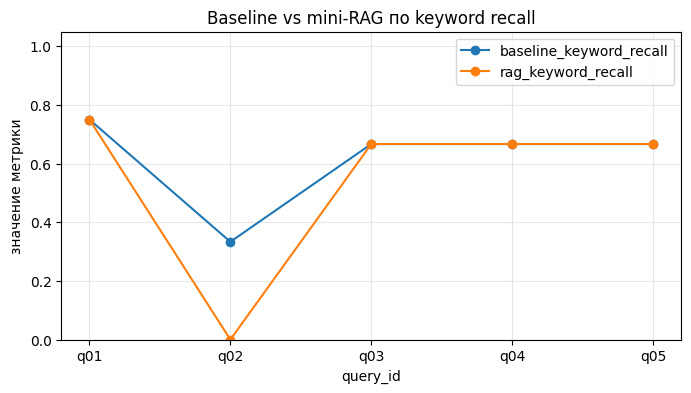

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [20]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q02,Эдипов комплек что это такое?,doc_07,"doc_05, doc_03, doc_08",0,0.333333,0.000000,Эдипов комплекс возникает в фаллической стадии...,Либидо в психоанализе – это психическая энерги...
1,q03,Парапраксис это?,doc_017,"doc_017, doc_03, doc_08",1,0.666667,0.666667,"Парапраксис, или оговорка по Фрейду, – это оши...","Парапраксис, или оговорка по Фрейду, – это оши..."
2,q04,Кто такие неофрейдисты?,doc_15,"doc_06, doc_15, doc_09",1,0.666667,0.666667,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот...","Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
3,q05,Что значит перенос в терапии?,doc_10,"doc_10, doc_11, doc_18",1,0.666667,0.666667,Анализ переноса является ключевым инструментом...,Анализ переноса является ключевым инструментом...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [21]:
for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Слабый кейс: Эдипов комплек что это такое?

**Ответ mini-RAG:** Либидо в психоанализе – это психическая энергия сексуальных влечений.

,rank,score,doc_id,title,chunk_text
0,1,0.359725,doc_05,Толкование сновидений,Фрейд называл сновидения «королевской дорогой ...
1,2,0.358030,doc_03,"Структура личности: Оно, Я, Сверх-Я",Фрейд выделил три инстанции психики: Оно (инст...
2,3,0.309610,doc_08,Либидо и инстинкты,Либидо в психоанализе – это психическая энерги...


### Слабый кейс: Парапраксис это?

**Ответ mini-RAG:** Парапраксис, или оговорка по Фрейду, – это ошибка в речи, письме или действии. Либидо в психоанализе – это психическая энергия сексуальных влечений.

...

**Ответ mini-RAG:** Неофрейдисты (Фромм, Хорни, Салливан) пересмотрели биологизаторский подход Фрейда.

,rank,score,doc_id,title,chunk_text
0,1,0.475251,doc_06,Психосексуальное развитие,"Психоанализ предполагает, что личность формиру..."
1,2,0.473103,doc_15,Неофрейдизм,"Неофрейдисты (Фромм, Хорни, Салливан) пересмот..."
2,3,0.397250,doc_09,Метод свободных ассоциаций,Свободные ассоциации – основной технический пр...


### Слабый кейс: Что значит перенос в терапии?

**Ответ mini-RAG:** Анализ переноса является ключевым инструментом терапии. Перенос – это процесс, когда пациент бессознательно проецирует на аналитика чувства к значимым фигурам прошлого.

,rank,score,doc_id,title,chunk_text
0,1,0.716747,doc_10,Перенос в терапии,"Перенос – это процесс, когда пациент бессознат..."
1,2,0.567718,doc_11,Контрперенос,Контрперенос – это эмоциональная реакция анали...
2,3,0.506383,doc_18,Сеттинг в психоанализе,"Сеттинг – это постоянные рамки терапии: время,..."


In [22]:
results_retrieval_eval = [
    {
        "query": row["query"],
        "expected_source": row["relevant_doc_ids"],
        "retrieved_sources": row["predicted_doc_ids"],
        "hit_at_k": int(row["hit@3"]),
        "rank_of_first_relevant": row["first_relevant_rank"] if pd.notna(row["first_relevant_rank"]) else None,
    }
    for _, row in baseline_eval_k3.iterrows()
]

df_retrieval_eval = pd.DataFrame(results_retrieval_eval)

output_path_retrieval_eval = './artifacts/retrieval_eval.csv'

df_retrieval_eval.to_csv(output_path_retrieval_eval, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_eval.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_eval.csv


In [23]:
results_rag_examples = [
    {
        "question": "Что такое либидо?",
        "answer": "Либидо в психоанализе – это психическая энергия сексуальных влечений. Считается, что такие ошибки не случайны, а выявляют скрытые мысли или",
        "retrieved_sources": "doc_08; doc_017; doc_13",
    },
    {
        "question": "Парапраксис это?",
        "answer": " Парапраксис, или оговорка по Фрейду, – это ошибка в речи, письме или действии. Либидо в психоанализе – это психическая энергия сексуальных влечений.",
        "retrieved_sources": "doc_017; doc_03; doc_08",
    },
    {
        "question": "Кто такие неофрейдисты?",
        "answer": "Неофрейдисты (Фромм, Хорни, Салливан) пересмотрели биологизаторский подход Фрейда.",
        "retrieved_sources": "doc_06; doc_15; doc_09",
    },
]

df_rag_examples = pd.DataFrame(results_rag_examples)

output_path_rag_examples = './artifacts/rag_examples.csv'

df_rag_examples.to_csv(output_path_rag_examples, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/rag_examples.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/rag_examples.csv


In [24]:
results_retrieval_before_after_update = [
    {
        "query": "Кто основал психоанализ и какие идеи лежат в его основе?",
        "before_retrieved_sources": "doc_01, doc_20, doc_02",
        "after_retrieved_sources": "doc_01, doc_20, doc_02",
        "changed": False
    },
    {
        "query": "Что такое бессознательное в психоанализе??",
        "before_retrieved_sources": "doc_02, doc_01, doc_13",
        "after_retrieved_sources": "doc_02, doc_13, doc_01",
        "changed": False
    },
    {
        "query": "Из каких частей состоит структура личности по Фрейду?",
        "before_retrieved_sources": "doc_13, doc_06",
        "after_retrieved_sources": "doc_13, doc_16",
        "changed": True
    },
    {
        "query": "Какие защитные механизмы психики выделяет психоанализ?",
        "before_retrieved_sources": "doc_20, doc_01, doc_02	",
        "after_retrieved_sources": "doc_20, doc_01, doc_21",
        "changed": True
    },
    {
        "query": "Почему сновидения важны для психоанализа?",
        "before_retrieved_sources": "doc_05, doc_02, doc_08",
        "after_retrieved_sources": "doc_05, doc_02, doc_017",
        "changed": True
    },
    {
        "query": "Какие стадии психосексуального развития описывает Фрейд?",
        "before_retrieved_sources": "doc_06, doc_20, doc_07	",
        "after_retrieved_sources": "doc_06, doc_01, doc_20",
        "changed": True
    },
    {
        "query": "Как рассматривал Фрейд великие произведения культуры?",
        "before_retrieved_sources": "doc_15, doc_13, doc_01",
        "after_retrieved_sources": "doc_23, doc_15, doc_22",
        "changed": True
    },
    {
        "query": "Что подчеркивал Лакан?",
        "before_retrieved_sources": "doc_03, doc_08, doc_16",
        "after_retrieved_sources": "doc_23, doc_03",
        "changed": True
    }
]

df_retrieval_before_after_update = pd.DataFrame(results_retrieval_before_after_update)

output_path_retrieval_before_after_update = './artifacts/retrieval_before_after_update.csv'

df_retrieval_before_after_update.to_csv(output_path_retrieval_before_after_update, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_before_after_update.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/retrieval_before_after_update.csv
